<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/%EC%BB%B4%ED%93%A8%ED%84%B0%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EC%B4%88/%EC%9C%84%EC%84%B1%EC%98%81%EC%83%81%EB%B6%84%EB%A5%98_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# numpy 1.x + imgaug 설치
!pip uninstall -y numpy imgaug
!pip install "numpy<2.0" "imgaug==0.4.0"

# 런타임 재시작 필요
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have num

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/file/위성 영상을 통한 허리케인 피해 가옥 분류,데이터셋.zip" -d "/content/위성영상"

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/위성영상/9/train/damage/-95.162359_30.024707.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.59979399999999_29.603763.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.554749_29.766663.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.647092_29.838645.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.633773_29.774760999999998.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.63417_29.769978000000002.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.63255500000001_29.858689000000002.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.64211999999999_29.843186.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.640284_29.771431.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.611561_29.757592.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.114769_30.013926.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.558665_29.769089.jpeg  
  inflating: /content/위성영상/9/train/damage/-95.611042_29.763571999999996.jp

In [3]:
!ls "/content/위성영상/9/test"

damage	normal


In [4]:
# 표준 라이브러리
import os         # 파일/디렉토리 경로 처리
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image   # 이미지 입출력/변환 (PIL 이미지 객체)
from tqdm import tqdm

import torch            # 텐서, 자동미분, 디바이스(GPU/CPU) 제어
import torch.nn as nn   # 신경망 계층(Conv2d, Linear BatchNorm 등), 손실 함수
import torch.optim as optim # 최적화 알고리즘(Adam, SGD, RAdam 등)

from torch.utils.data import DataLoader, Dataset
# Dataset: 사용자 정의 데이터셋 클래스 작성시 상속 (__len__/ __getitem__ )
# DataLoader: 배치 단위 데이터 로딩, 셔플, 병렬 로딩 지원

from torchvision.utils import make_grid
# 여러 이미지를 격자 형태로 합쳐 시각화

from torchvision.datasets import ImageFolder
# 폴더 구조 기반 데이터셋

import torchvision.transforms as transforms
# 데이터 전처리 및 증강(Resize, ToTensor, Normalize, RandomFlip 등)

import torchvision.models as models
# 사전 학습된 모델 불러오기(ResNet, VGG 등)

In [5]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
print('Device:', device)

Device: cuda


In [7]:
# 이미지를 출력하는 함수
def display_images(image_paths, title, max_images=4):
  """지정된 경로의 이미지를 최대 4개까지 출력합니다."""
  plt.figure(figsize=(12, 3))   # 전체 출력될 그림의 크기 지정

  # enumerate를 사용하여 이미지 경로를 순회 (인덱스 i, 경로 image_path 반환)
  for i, image_path in enumerate(image_paths[:max_images]):
    img = plt.imread(image_path)      # 이미지 파일 읽기 (numpy 배열로 로드)
    plt.subplot(1, max_images, i+1)
    plt.imshow(img)                   # 이미지를 현재 subplot에 출력
    plt.title(title)
    plt.axis('off')

  plt.show()    # 모든 subplot을 화면에 표시

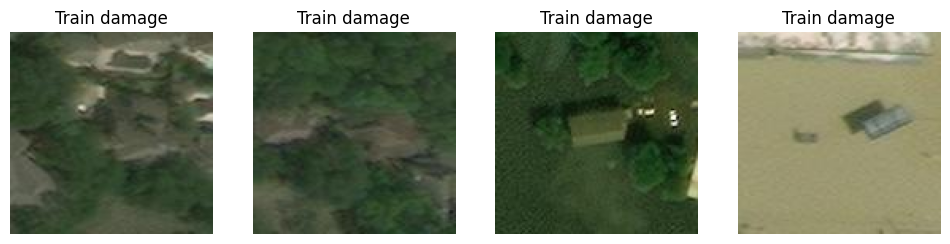

Train damage 총 이미지 수: 5900


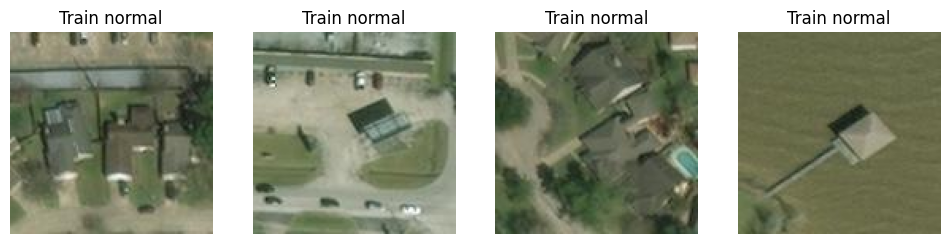

Train normal 총 이미지 수: 5901


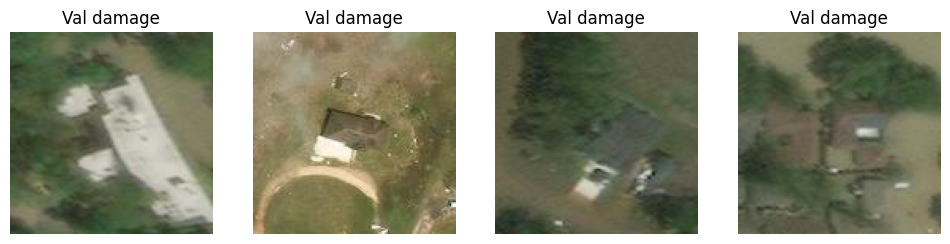

Val damage 총 이미지 수: 1000


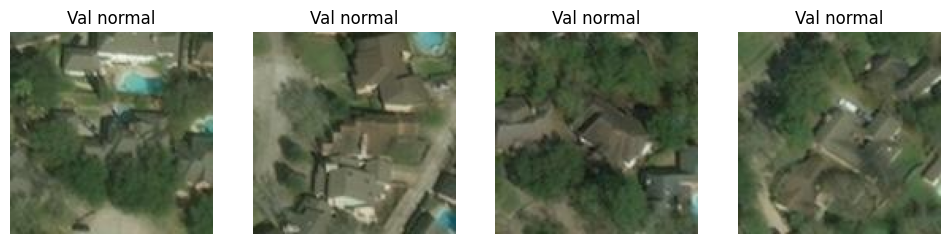

Val normal 총 이미지 수: 1000


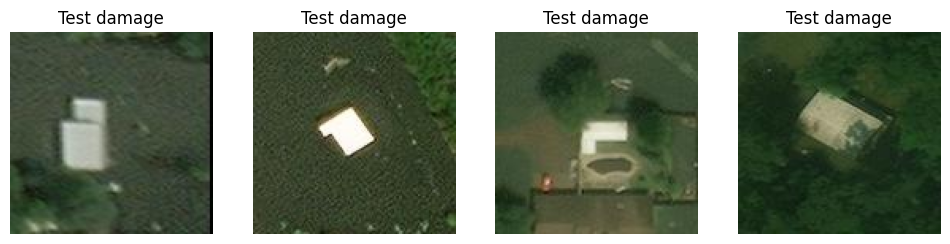

Test damage 총 이미지 수: 100


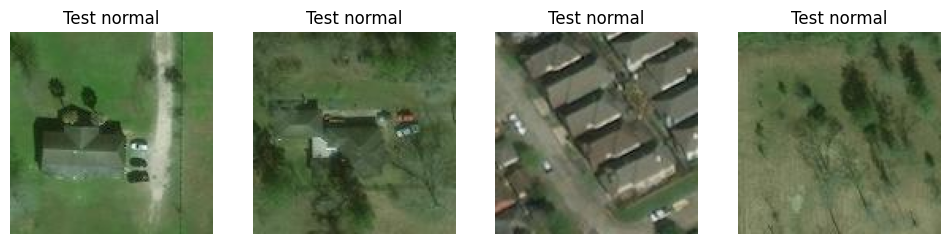

Test normal 총 이미지 수: 100


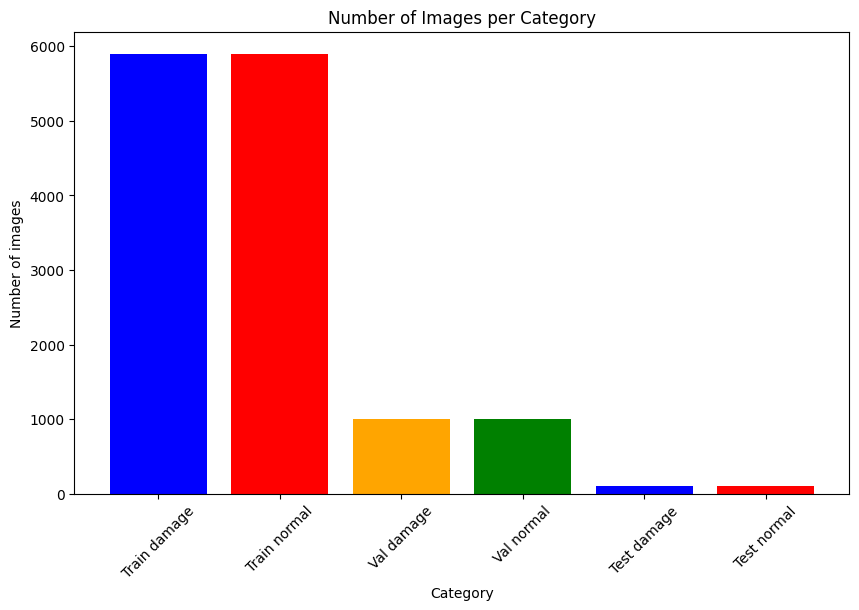

In [8]:
# 이미지와 바 그래프 출력
categories = ['Train damage', 'Train normal', 'Val damage', 'Val normal', 'Test damage', 'Test normal']

for category in categories:
  image_paths = glob.glob(f'/content/위성영상/9/{category.lower().replace(" ","/")}/*')
  display_images(image_paths, category)
  print(f'{category} 총 이미지 수: {len(image_paths)}')

# 바 그래프 설정
plt.figure(figsize=(10, 6))
plt.bar(categories, [len(glob.glob(f'/content/위성영상/9/{category.lower().replace(" ","/")}/*')) for category in categories], color=['blue','red','orange','green'])
plt.title('Number of Images per Category')
plt.xlabel('Category')
plt.ylabel('Number of images')
plt.xticks(rotation=45)
plt.show()

In [9]:
from imgaug import augmenters as iaa
import imgaug as ia

# imgaug를 사용한 커스텀 데이터셋 정의
class ImgAugTransform:
  def __init__(self):
    # 여러 증강 기법을 순차적으로 적용하기 위해 Sequential 사용
    self.aug = iaa.Sequential([
        iaa.LinearContrast((0.75, 1.5)), # 이미지 대비를 0.75~1.5배 사이에서 무작위 조정
        iaa.Fliplr(0.5),
        iaa.Flipud(0.2),
    ])


  def __call__(self, img):
    # PIL.Image 객체를 numpy 배열로 변환 (imgaug는 numpy 배열 기반으로 동작)
    img = np.array(img)
    # 설정된 증강 기법들을 적용한 이미지를 반환
    return self.aug.augment_image(img)

In [10]:
# 커스텀 데이터셋 클래스
class CustomDataset(ImageFolder):
  def __init__(self, root, imgaug=None, transform=None, sample_per_class=None):
    # ImageFolder를 상속하여 root 경로 기반으로 클래스별 데이터셋 생성
    super(CustomDataset, self).__init__(root, transform=transform)
    self.imgaug_transform = imgaug # imgaug 변환기를 저장 (데이터 증강에 사용)

    # 클래스별 샘플 수를 제한하고 싶을 경우 적용
    if sample_per_class is not None:
      self.samples = self._reduce_samples(sample_per_class)

  def _reduce_samples(self, sample_per_class):
    """
    클래스별 데이터 개수를 sample_per_class로 제한.
    즉, 각 클래스에서 일정 개수만 랜덤 샘플링하여 학습에 사용.
    """
    class_samples = {}    # 클래스별로 경로를 모아둘 딕셔너리
    for path, target in self.samples:
      if target not in class_samples:
        class_samples[target] = [path] # 해당 클래스 첫 샘플
      else:
        class_samples[target].append(path)

    reduced_samples = [] # 줄여진 샘플 리스트
    for target, paths in class_samples.items():
      # 만약 샘플이 너무 많으면 지정한 수만큼 랜덤 추출
      if len(paths) > sample_per_class:
        reduced_samples.extend([(path, target) for path in random.sample(paths, sample_per_class)])
      else:
        # 적으면 그냥 전부 사용
        reduced_samples.extend([(path, target) for path in paths])

    return reduced_samples

def __getitem__(self, index):
  # 주어진 인덱스에 해당하는 이미지 경로와 레이블 가져오기
  path, target = self.samples[index]
  img = self.loader(path) # PIL Image로 로드

  # imgaug 증강 적용 (numpy 기반)
  if self.imgaug_transform is not None:
    img = self.imgaug_transform(img) # numpy 배열 반환
    img = Image.fromarray(img)       # 다시 PIL Image로 변환

  # torchvision.transforms 적용 (Tensor 변환, Normalize 등)
  if self.transform is not None:
    img = self.transform(img)

  return img, target

In [11]:
# PyTorch transforms에서 ToTensor 및 Normalize만 적용
from torchvision import transforms

pytorch_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [12]:
# 데이터셋 및 데이터 로더 초기화
train_path = '/content/위성영상/9/train'
val_path = '/content/위성영상/9/val'

train_dataset = CustomDataset(train_path, imgaug=ImgAugTransform(), transform = pytorch_transforms)
val_dataset = CustomDataset(val_path, imgaug=None, transform=pytorch_transforms, sample_per_class=128)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [14]:
# DataLoader에서 샘플 이미지를 load해 show하는 함수
def imshow(img, size=(20,20), mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
  # 텐서를 넘파이 배열로 변환하고 차원 순서를 변경
  img = img.numpy().transpose((1,2,0))

  # 정규화 해제
  mean = np.array(mean)
  std = np.array(std)
  img = std * img + mean

  # 값이 0~1 사이에 있도록 강제 조정
  img = np.clip(img, 0, 1)

  # 이미지 출력
  plt.figure(figsize=size)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

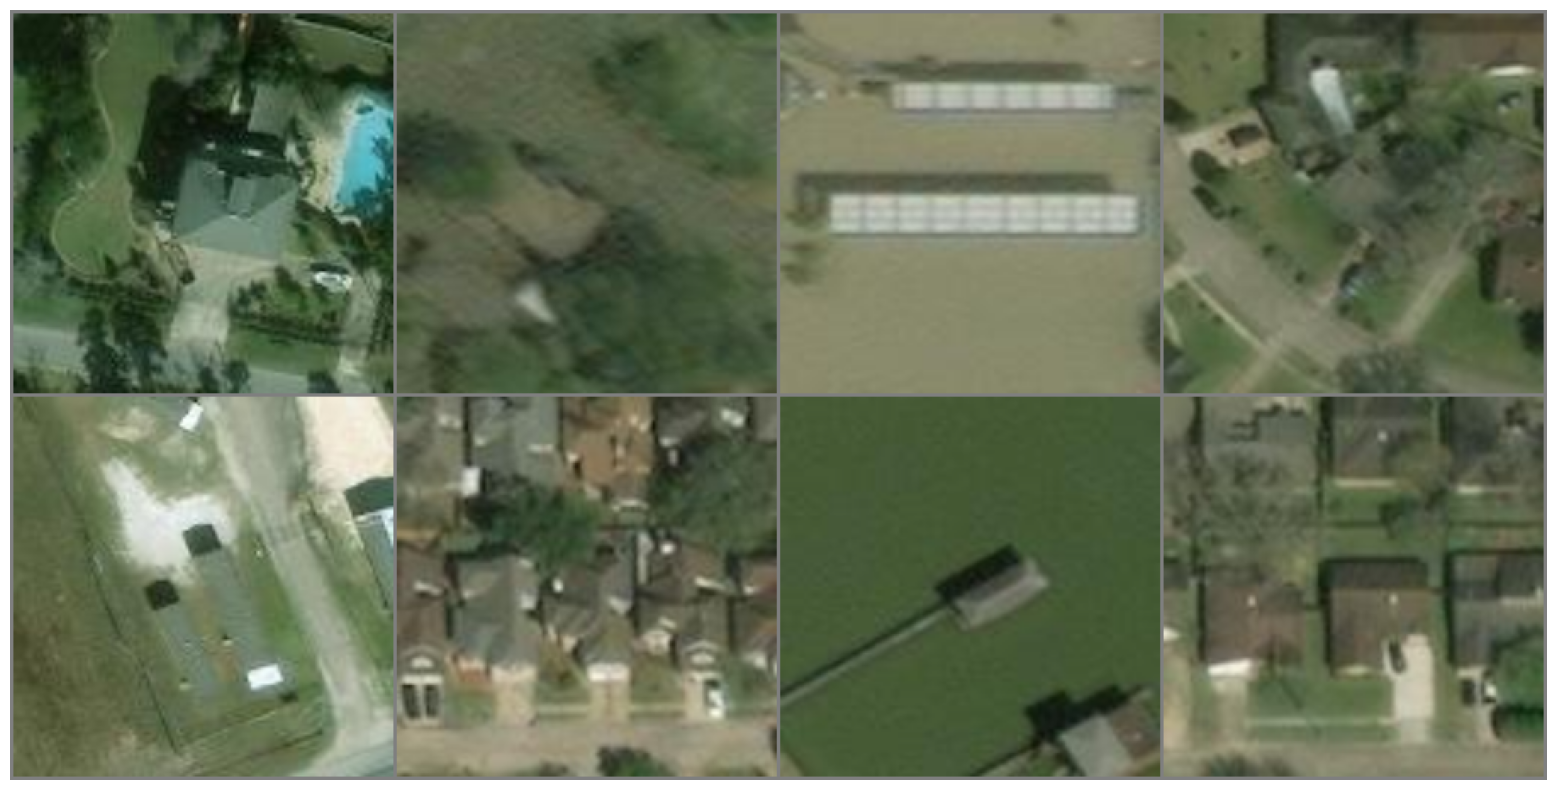

In [15]:
# DataLoader를 이용해 배치 데이터 가져오기
dataiter = iter(train_loader)
images, _ = next(dataiter)

imshow(make_grid(images[:8], nrow=4), size=(20,10))

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict

# ---------------------------
# DenseNet의 기본 구성 요소들
# ---------------------------

class _DenseLayer(nn.Sequential):
    def __init__(self, num_input_features, growth_rate, bn_size, drop_rate):
        """
        DenseNet의 한 레이어(Composite function = BN-ReLU-Conv(1x1)-BN-ReLU-Conv(3x3)).
        - num_input_features: 입력 채널 수 (이전까지 concat된 특징 수)
        - growth_rate: 각 레이어가 새로 만들어 내는 채널 수 (k)
        - bn_size: BottleNeck 비율 (1x1 conv의 확장 채널 배수)
        - drop_rate: 드롭아웃 확률
        """
        super(_DenseLayer, self).__init__()
        # 1x1 컨볼루션(병목 레이어): 채널 수를 bn_size * growth_rate로 확장
        self.add_module('norm1', nn.BatchNorm2d(num_input_features)),
        self.add_module('relu1', nn.ReLU(inplace=True)),
        self.add_module('conv1', nn.Conv2d(
            num_input_features,
            bn_size * growth_rate,
            kernel_size=1, stride=1, bias=False
        )),
        # 3x3 컨볼루션: 최종적으로 growth_rate 채널 생성
        self.add_module('norm2', nn.BatchNorm2d(bn_size * growth_rate)),
        self.add_module('relu2', nn.ReLU(inplace=True)),
        self.add_module('conv2', nn.Conv2d(
            bn_size * growth_rate,
            growth_rate,
            kernel_size=3, stride=1, padding=1, bias=False
        )),
        self.drop_rate = drop_rate

    def forward(self, x):
        # Sequential에 등록된 모듈들을 통과 → 새로 생성된 feature maps
        new_features = super(_DenseLayer, self).forward(x)
        # 필요 시 드롭아웃 적용
        if self.drop_rate > 0:
            new_features = F.dropout(new_features, p=self.drop_rate, training=self.training)
        # DenseNet의 핵심: 입력 x와 새 특징 new_features를 채널 방향(cat dim=1)으로 연결
        return torch.cat([x, new_features], dim=1)


class _DenseBlock(nn.Sequential):
    def __init__(self, num_layers, num_input_features, bn_size, growth_rate, drop_rate):
        """
        여러 개의 _DenseLayer로 이루어진 블록.
        각 레이어가 이전까지의 모든 출력을 concat해서 입력으로 받음.
        """
        super(_DenseBlock, self).__init__()
        for i in range(num_layers):
            # i번째 레이어의 입력 채널 = 초기 입력 + (이전 레이어 수 * growth_rate)
            layer = _DenseLayer(
                num_input_features + i * growth_rate,
                growth_rate,
                bn_size,
                drop_rate
            )
            self.add_module(f'denselayer{i + 1}', layer)


class _Transition(nn.Sequential):
    def __init__(self, num_input_features, num_output_features):
        """
        DenseBlock 사이에 위치하는 전이(Transition) 레이어.
        - 채널 수를 줄이고(1x1 conv), 공간 크기를 절반으로 다운샘플링(AvgPool2d).
        """
        super(_Transition, self).__init__()
        self.add_module('norm', nn.BatchNorm2d(num_input_features))
        self.add_module('relu', nn.ReLU(inplace=True))
        self.add_module('conv', nn.Conv2d(
            num_input_features,
            num_output_features,
            kernel_size=1, stride=1, bias=False
        ))
        self.add_module('pool', nn.AvgPool2d(kernel_size=2, stride=2))


# ---------------------------
# DenseNet-169 정의
# ---------------------------
class densenet169(nn.Module):
    def __init__(
        self,
        growth_rate=32,                 # k: 레이어마다 증가하는 채널 수
        block_config=(6, 12, 32, 32),   # 각 DenseBlock의 레이어 개수(169 아키텍처)
        num_init_features=64,           # 초기 stem 출력 채널 수
        bn_size=4,                      # bottleneck 확장 비율
        drop_rate=0,                    # 드롭아웃 확률
        num_classes=1000                # 최종 분류 클래스 수
    ):
        super(densenet169, self).__init__()

        # Stem: 초기 컨볼루션/풀링
        self.features = nn.Sequential(OrderedDict([
            # 7x7 conv, stride=2로 다운샘플링
            ('conv0', nn.Conv2d(3, num_init_features, kernel_size=7, stride=2, padding=3, bias=False)),
            ('norm0', nn.BatchNorm2d(num_init_features)),
            ('relu0', nn.ReLU(inplace=True)),
            # 3x3 maxpool, stride=2로 추가 다운샘플링
            ('pool0', nn.MaxPool2d(kernel_size=3, stride=2, padding=1)),
        ]))

        # DenseBlock들 + Transition들 구성
        num_features = num_init_features
        for i, num_layers in enumerate(block_config):
            # DenseBlock 추가
            block = _DenseBlock(
                num_layers=num_layers,
                num_input_features=num_features,
                bn_size=bn_size,
                growth_rate=growth_rate,
                drop_rate=drop_rate
            )
            self.features.add_module(f'denseblock{i + 1}', block)
            # 블록을 지나면 채널 수가 growth_rate * num_layers 만큼 증가
            num_features = num_features + num_layers * growth_rate

            # 마지막 블록이 아니라면 Transition으로 채널/해상도 축소
            if i != len(block_config) - 1:
                trans = _Transition(
                    num_input_features=num_features,
                    num_output_features=num_features // 2
                )
                self.features.add_module(f'transition{i + 1}', trans)
                num_features = num_features // 2

        # 마지막에 BN 한 번 더
        self.features.add_module('norm5', nn.BatchNorm2d(num_features))

        # 분류기: Global pooling 후 Linear
        self.classifier = nn.Linear(num_features, num_classes)

        # 공식 초기화 방식 (Kaiming for Conv, 1/0 for BN, 0 for Linear bias)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)   # He 초기화
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)      # BN scale=1
                nn.init.constant_(m.bias, 0)        # BN bias=0
            elif isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, 0)        # FC bias=0

    def forward(self, x):
        # 특징 추출기 통과 (Stem + DenseBlocks + Transitions + BN)
        features = self.features(x)
        # 마지막 활성화
        out = F.relu(features, inplace=True)
        # Global Average Pooling (H,W → 1,1)
        out = F.adaptive_avg_pool2d(out, (1, 1))
        # (N, C, 1, 1) → (N, C)
        out = torch.flatten(out, 1)
        # 최종 분류
        out = self.classifier(out)
        return out


In [17]:
# 사전 학습된 densenet169 모델 불러오기
pretrained_densenet169 = models.densenet169(pretrained=True)
# 새로 정의한 모델 인스턴스 생성
net = densenet169(num_classes=1000)


# 사전 학습된 모델의 features 부분에서 가중치 추출
pretrained_keys = set(pretrained_densenet169.state_dict().keys())
# 사전 학습된 모델에서 커스텀 모델로 가중치 복사 시도
result = net.load_state_dict(pretrained_densenet169.state_dict(), strict=False)
# 복사 후 커스텀 모델의 features 부분에서 가중치 추출
custom_keys = set(net.state_dict().keys())


# 성공적으로 복사된 가중치 (커스텀 모델과 사전 학습된 모델 모두에 존재)
successfully_copied_keys = pretrained_keys.intersection(custom_keys)
# 커스텀 모델에 있지만 사전 학습된 모델에 없는 가중치
missing_keys = custom_keys - pretrained_keys
# 사전 학습된 모델에 있지만 커스텀 모델에 없는 가중치
unexpected_keys = pretrained_keys - custom_keys

print("성공적으로 복사된 가중치:", successfully_copied_keys)
print("커스텀 모델에는 있지만 사전 학습된 모델에는 없는 가중치 (누락):", result.missing_keys)
print("사전 학습된 모델에는 있지만 커스텀 모델에는 없는 가중치 (예상치 못한):", result.unexpected_keys) # net 모델에 없는데 pretrained_vgg19 가중치 파일에는 존재하는 항목의 이름이 리스트로 반환

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 91.0MB/s]


성공적으로 복사된 가중치: {'features.denseblock2.denselayer5.norm1.weight', 'features.denseblock4.denselayer9.norm2.num_batches_tracked', 'features.denseblock3.denselayer20.norm2.num_batches_tracked', 'features.denseblock2.denselayer6.norm2.weight', 'features.denseblock3.denselayer1.norm2.weight', 'features.denseblock2.denselayer8.norm1.weight', 'features.denseblock4.denselayer2.norm2.weight', 'features.denseblock3.denselayer7.conv1.weight', 'features.denseblock4.denselayer16.norm2.running_var', 'features.denseblock2.denselayer2.norm2.bias', 'features.denseblock4.denselayer27.norm2.weight', 'features.denseblock3.denselayer6.norm2.num_batches_tracked', 'features.denseblock3.denselayer11.norm2.running_mean', 'features.denseblock4.denselayer19.norm1.weight', 'features.denseblock4.denselayer24.norm2.num_batches_tracked', 'features.denseblock4.denselayer26.norm1.num_batches_tracked', 'features.denseblock3.denselayer3.norm1.running_var', 'features.denseblock3.denselayer29.norm2.running_mean', 'features

In [18]:
print(net)

densenet169(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (r

In [20]:
# 모델의 모든 파라미터를 고정
for param in net.parameters():
  param.requires_grad = False

In [21]:
# classifier 부분의 가중치는 재학습을 위해 새로 정의
net.classifier = nn.Linear(1664, 1)

for param in net.classifier.parameters():
  param.requires_grad = True

net = net.to(device)

In [22]:
# 손실 함수
criterion = nn.BCEWithLogitsLoss()

In [23]:
def validate_model(net, val_loader, criterion):
  net.eval()        # 모델을 평가 모드로 설정
  val_loss = 0.0    # 검증 손실 누적 값
  correct = 0       # 맞춘 샘플 개수
  total = 0         # 전체 샘플 개수


  with torch.no_grad():     # 검증 단계에서는 gradient 계산을 하지 않음
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)

      # Binary Classification 대비: 레이블을 float형 + 차원 (batch_size, 1) 형태로 맞춤
      labels = labels.float().unsqueeze(1)

      # 모델 추론
      outputs = net(inputs)

      # 손실 값 계산
      loss = criterion(outputs, labels).item()

      # sigmoid 함수로 확률화 -> 0.5 기준으로 예측
      predicted = torch.sigmoid(outputs) > 0.5

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  val_loss /= len(val_loader)

  val_accuracy = 100 * correct / total

  return val_loss, val_accuracy

In [24]:
def train_model(optimizer_name, net, train_loader, val_loader, criterion, num_epochs=10):
  # optimizer 설정
  if optimizer_name == 'SGD':
    optimizer = optim.SGD(net.parameters(), lr=0.00003, momentum=0.9)
  elif optimizer_name == 'Adam':
    optimizer = optim.Adam(net.parameters(), lr=0.00003, betas=(0.9, 0.999))
  elif optimizer_name == 'RAdam':
    optimizer = optim.RAdam(net.parameters(), lr=0.00003, betas=(0.9, 0.999))
  else:
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")

  train_losses = []
  val_losses = []
  val_accuracies = []

  for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")):
      inputs, labels = inputs.to(device), labels.to(device)
      labels = labels.float().unsqueeze(1)
      optimizer.zero_grad()   # 이전 스텝의 gradient 초기화
      outputs = net(inputs)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()      # 가중치 갱신

      running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    val_loss, val_accuracy = validate_model(net, val_loader, criterion)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'[{optimizer_name}] Epoch {epoch + 1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Validation Accuracy: {val_accuracy:.2f}%')

  return train_losses, val_losses, val_accuracies

In [25]:
train_losses_RAdam, val_losses_RAdam, val_accuracies_RAdam = train_model('RAdam', net, train_loader, val_loader, criterion)

Epoch 1/10: 100%|██████████| 369/369 [01:16<00:00,  4.86it/s]


[RAdam] Epoch 1, Train Loss: 0.694603, Val Loss: 0.000000, Validation Accuracy: 58.98%


Epoch 2/10: 100%|██████████| 369/369 [01:14<00:00,  4.96it/s]


[RAdam] Epoch 2, Train Loss: 0.640768, Val Loss: 0.000000, Validation Accuracy: 74.22%


Epoch 3/10: 100%|██████████| 369/369 [01:19<00:00,  4.61it/s]


...

[RAdam] Epoch 8, Train Loss: 0.372606, Val Loss: 0.000000, Validation Accuracy: 89.06%


Epoch 9/10: 100%|██████████| 369/369 [01:19<00:00,  4.62it/s]


[RAdam] Epoch 9, Train Loss: 0.349264, Val Loss: 0.000000, Validation Accuracy: 89.06%


Epoch 10/10: 100%|██████████| 369/369 [01:21<00:00,  4.53it/s]


[RAdam] Epoch 10, Train Loss: 0.326886, Val Loss: 0.000000, Validation Accuracy: 88.67%


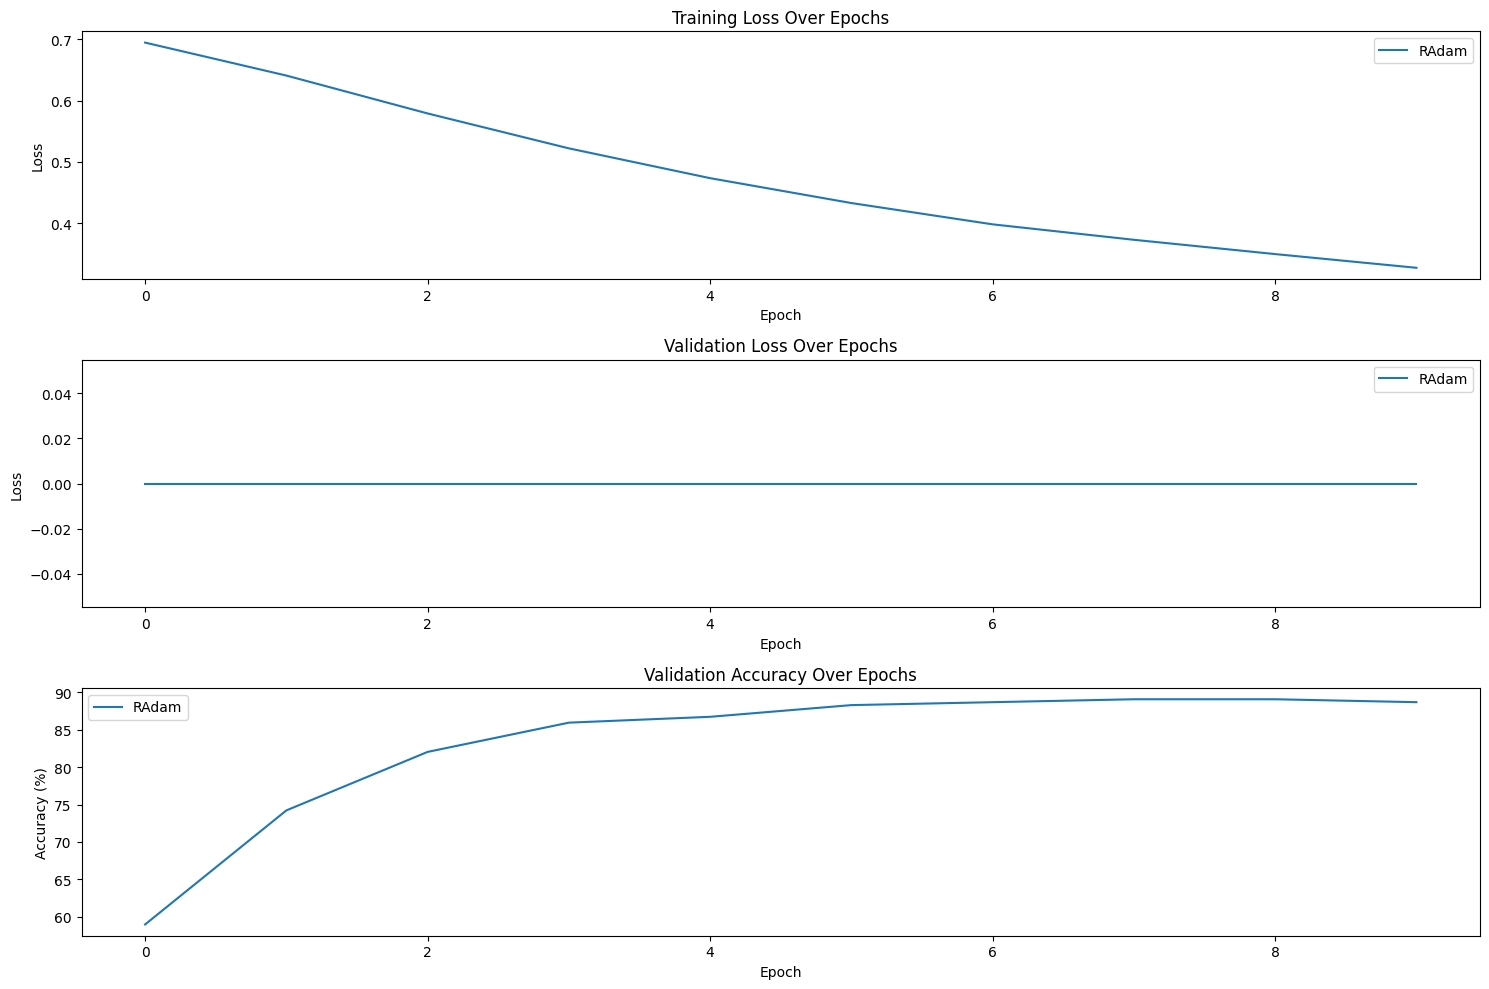

In [26]:
# 학습 손실과 검증 정확도 그래프 그리기
plt.figure(figsize=(15, 10))

# 학습 손실 그래프
plt.subplot(3, 1, 1)  # 3행 1열의 첫 번째 위치
plt.plot(train_losses_RAdam, label='RAdam')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# 검증 손실 그래프
plt.subplot(3, 1, 2)  # 3행 1열의 두 번째 위치
plt.plot(val_losses_RAdam, label='RAdam')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()

# 검증 정확도 그래프
plt.subplot(3, 1, 3)  # 3행 1열의 세 번째 위치
plt.plot(val_accuracies_RAdam, label='RAdam')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# Image load 및 tensor로 변환
def load_and_transform_image(image_path, transform):
  image = Image.open(image_path).convert('RGB')
  return transform(image).unsqueeze(0).to(device) # 이미지를 모델에 맞게 변환하고 배치 차원 추가

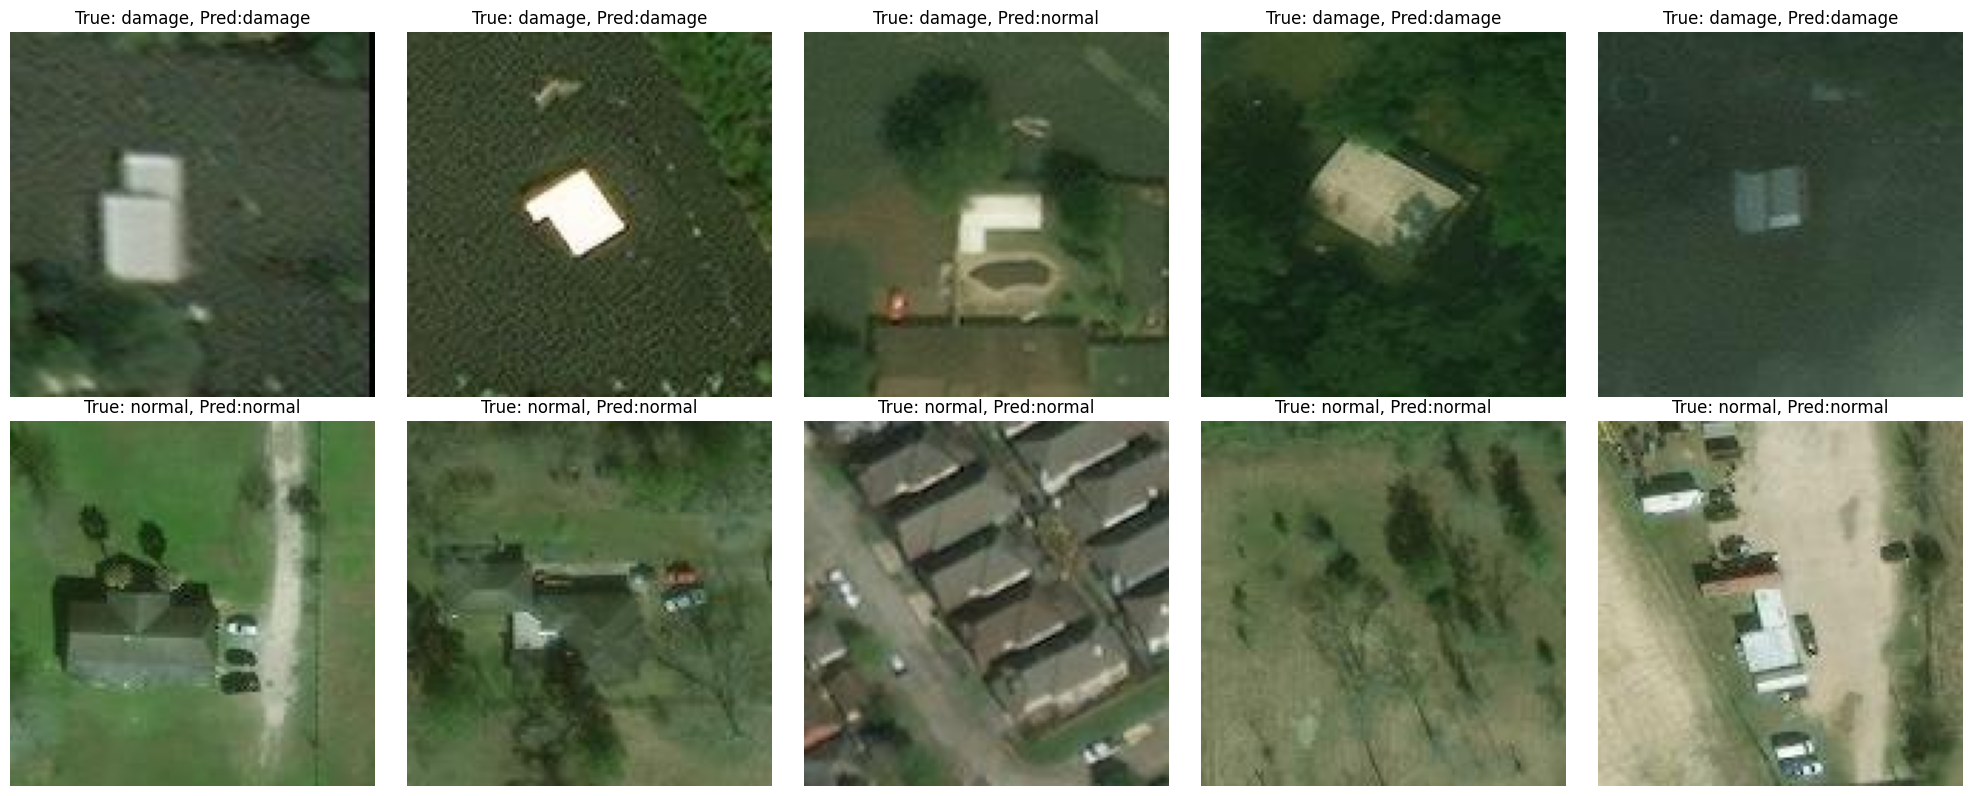

In [28]:
class_folders = {
    'damage': '/content/위성영상/9/test/damage',
    'normal': '/content/위성영상/9/test/normal'
}

plt.figure(figsize=(20,8))

counter = 1

for class_name, folder_path in class_folders.items():
  image_paths = glob.glob(os.path.join(folder_path, '*'))
  selected_paths = image_paths[:5]

  for image_path in selected_paths:
    image = load_and_transform_image(image_path, pytorch_transforms)

    net.eval() # 모델을 평가 모드로 설정
    # 모델을 사용한 추론
    with torch.no_grad():
      outputs = net(image)
      # 시그모이드 함수 적용하여 확률 얻기
      probs = torch.sigmoid(outputs).item()
      prediction = 'normal' if probs > 0.5 else 'damage'

    # 결과 시각화
    plt.subplot(2, 5, counter)
    plt.imshow(Image.open(image_path))
    plt.title(f'True: {class_name}, Pred:{prediction}')
    plt.axis('off')

    counter += 1

plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, class_folders, transform):
  model.eval()    # 모델을 평가 모드로 설정
  model.to(device)

  all_preds = []
  all_labels = []

  # class_folders: {클래스이름: 폴더경로} 형태
  for class_name, folder_path in class_folders.items():
    image_paths = glob.glob(os.path.join(folder_path, '*'))

    for image_path in image_paths:
      image = load_and_transform_image(image_path, transform)

      with torch.no_grad():
        outputs = model(image)
        probs = torch.sigmoid(outputs).item()
        prediction = 1 if probs >= 0.5 else 0
        all_preds.append(prediction)
        all_labels.append(1 if class_name == 'normal' else 0)


  accuracy = accuracy_score(all_labels, all_preds)
  precision = precision_score(all_labels, all_preds)
  recall = recall_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds)

  return accuracy, precision, recall, f1




In [30]:
# Evaluate models
densenet_metrics = evaluate_model(net, class_folders, pytorch_transforms)

# Print comparison
print("densenet Metrics: Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}".format(*densenet_metrics))

densenet Metrics: Accuracy: 0.9650, Precision: 0.9697, Recall: 0.9600, F1: 0.9648
